In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

print("Import erfolgreich")

Import erfolgreich


In [2]:
# Normale Maschinendaten
np.random.seed(42)
normal = np.random.normal(loc=85, scale=3, size=200)

# Anomalien hinzufügen
anomalien = np.array([110, 115, 45, 120, 40])

# Kombinieren
daten = np.concatenate([normal, anomalien])
df = pd.DataFrame({"temperatur": daten})

print(f"Datenpunkte gesamt: {len(df)}")
print(f"Davon Anomalien: {len(anomalien)}")

Datenpunkte gesamt: 205
Davon Anomalien: 5


In [3]:
# Isolation Forest trainieren
modell = IsolationForest(contamination=0.02, random_state=42)
df["vorhersage"] = modell.fit_predict(df[["temperatur"]])

# -1 = Anomalie, 1 = Normal
df["label"] = df["vorhersage"].map({1: "Normal", -1: "Anomalie"})

print(df["label"].value_counts())
print("\nGefundene Anomalien:")
print(df[df["label"] == "Anomalie"]["temperatur"].values)

label
Normal      200
Anomalie      5
Name: count, dtype: int64

Gefundene Anomalien:
[110. 115.  45. 120.  40.]


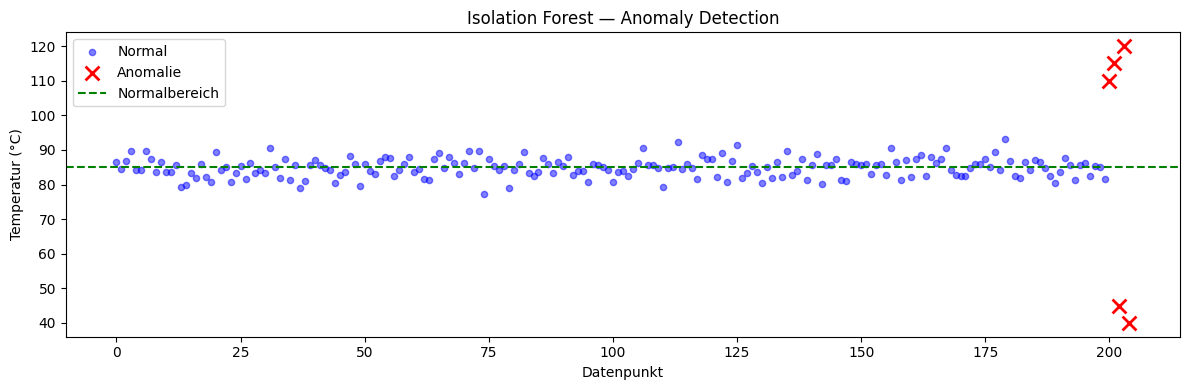

In [4]:
# Anomalien plotten
normal_data = df[df["label"] == "Normal"]
anomalie_data = df[df["label"] == "Anomalie"]

plt.figure(figsize=(12, 4))
plt.scatter(normal_data.index, normal_data["temperatur"],
            color="blue", label="Normal", alpha=0.5, s=20)
plt.scatter(anomalie_data.index, anomalie_data["temperatur"],
            color="red", label="Anomalie", s=100, marker="x", linewidths=2)
plt.axhline(y=85, color="green", linestyle="--", label="Normalbereich")
plt.title("Isolation Forest — Anomaly Detection")
plt.xlabel("Datenpunkt")
plt.ylabel("Temperatur (°C)")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Mehrere Sensoren simulieren
np.random.seed(42)
n = 300

normal_data = pd.DataFrame({
    "temperatur": np.random.normal(85, 3, n),
    "druck": np.random.normal(5, 0.5, n),
    "vibration": np.random.normal(1.5, 0.3, n)
})

# Anomalien hinzufügen
anomalie_data = pd.DataFrame({
    "temperatur": [115, 45, 110, 42, 118],
    "druck": [9.5, 1.0, 8.8, 1.2, 9.2],
    "vibration": [4.5, 0.1, 4.2, 0.2, 4.8]
})

df_multi = pd.concat([normal_data, anomalie_data], ignore_index=True)
print(f"Datenpunkte gesamt: {len(df_multi)}")

Datenpunkte gesamt: 305


In [6]:
# Isolation Forest auf mehreren Sensoren
modell_multi = IsolationForest(contamination=0.02, random_state=42)
df_multi["label"] = modell_multi.fit_predict(df_multi[["temperatur", "druck", "vibration"]])
df_multi["label"] = df_multi["label"].map({1: "Normal", -1: "Anomalie"})

print(df_multi["label"].value_counts())
print("\nGefundene Anomalien:")
print(df_multi[df_multi["label"] == "Anomalie"][["temperatur", "druck", "vibration"]])

label
Normal      298
Anomalie      7
Name: count, dtype: int64

Gefundene Anomalien:
     temperatur     druck  vibration
74    77.140765  6.076591   1.077746
262   75.276198  5.435562   1.964252
300  115.000000  9.500000   4.500000
301   45.000000  1.000000   0.100000
302  110.000000  8.800000   4.200000
303   42.000000  1.200000   0.200000
304  118.000000  9.200000   4.800000


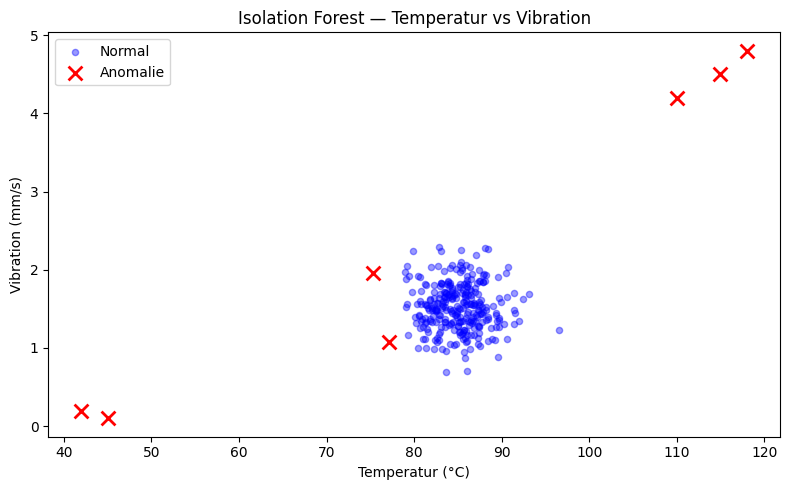

In [7]:
# 2D Plot: Temperatur vs Vibration
normal = df_multi[df_multi["label"] == "Normal"]
anomalie = df_multi[df_multi["label"] == "Anomalie"]

plt.figure(figsize=(8, 5))
plt.scatter(normal["temperatur"], normal["vibration"],
            color="blue", alpha=0.4, s=20, label="Normal")
plt.scatter(anomalie["temperatur"], anomalie["vibration"],
            color="red", s=100, marker="x", linewidths=2, label="Anomalie")
plt.title("Isolation Forest — Temperatur vs Vibration")
plt.xlabel("Temperatur (°C)")
plt.ylabel("Vibration (mm/s)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# CSV für Streamlit Test exportieren
df_multi[["temperatur", "druck", "vibration"]].to_csv("anomalie_test.csv", index=False)
print("CSV gespeichert")

CSV gespeichert
